In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from math import ceil
from tensorflow import keras # type: ignore
from tensorflow.keras import layers # type: ignore
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

sns.set_theme()

# Загрузка, нормализация и разбиение данных

In [2]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()

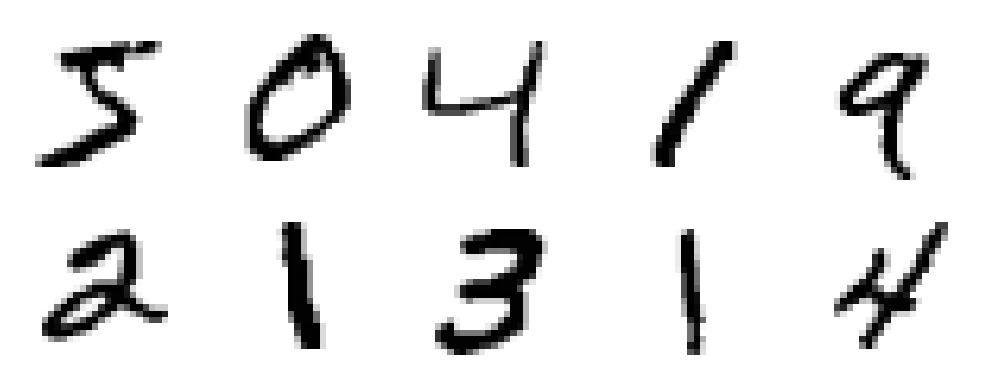

In [3]:
_, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 4))
axes = axes.flatten()
for ax, x in zip(axes, x_train_full):
    ax.axis("off")
    ax.imshow(x, cmap="gray_r")
plt.tight_layout()

In [4]:
print(x_train_full.shape, y_train_full.shape, x_test.shape, y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [5]:
train_counts = np.bincount(y_train_full)
train_percents = (train_counts / len(y_train_full)) * 100

train_stats = pd.DataFrame({
    "Цифра": range(10),
    "Количество": train_counts,
    "Доля (%)": train_percents.round(2)
})
train_stats["Доля (%)"] = train_stats["Доля (%)"].astype(str)

test_counts = np.bincount(y_test)
test_percents = (test_counts / len(y_test)) * 100

test_stats = pd.DataFrame({
    "Цифра": range(10),
    "Количество": test_counts,
    "Доля (%)": test_percents.round(2)
})
test_stats["Доля (%)"] = test_stats["Доля (%)"].astype(str)

print("Распределение цифр в обучающей выборке:")
display(train_stats.style.hide(axis="index"))

print("Распределение цифр в тестовой выборке:")
display(test_stats.style.hide(axis="index"))

Распределение цифр в обучающей выборке:


Цифра,Количество,Доля (%)
0,5923,9.87
1,6742,11.24
2,5958,9.93
3,6131,10.22
4,5842,9.74
5,5421,9.04
6,5918,9.86
7,6265,10.44
8,5851,9.75
9,5949,9.92


Распределение цифр в тестовой выборке:


Цифра,Количество,Доля (%)
0,980,9.8
1,1135,11.35
2,1032,10.32
3,1010,10.1
4,982,9.82
5,892,8.92
6,958,9.58
7,1028,10.28
8,974,9.74
9,1009,10.09


In [6]:
input_shape = (784,)

x_train_full = x_train_full.reshape(-1, input_shape[0]) / 255
x_test = x_test.reshape(-1, input_shape[0]) / 255

y_train_full = keras.utils.to_categorical(y_train_full, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print(x_train_full.shape, y_train_full.shape, x_test.shape, y_test.shape)

(60000, 784) (60000, 10) (10000, 784) (10000, 10)


In [7]:
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=0
)

print(x_train.shape, x_valid.shape, y_train.shape, y_valid.shape)

(48000, 784) (12000, 784) (48000, 10) (12000, 10)


# Создание и обучение моделей

In [8]:
model1 = keras.Sequential([
    layers.Input(shape=input_shape),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model1.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model2 = keras.Sequential([
    layers.Input(shape=input_shape),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model2.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model3 = keras.Sequential([
    layers.Input(shape=input_shape),
    layers.Dense(512, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model3.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 575,050 (2.19 MB)

 Trainable params: 575,050 (2.19 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
batch_size = 512
n_epochs = 15

history1 = model1.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=n_epochs,
    validation_data=(x_valid, y_valid)
)

Epoch 1/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8176 - loss: 0.6536 - val_accuracy: 0.9223 - val_loss: 0.2585
Epoch 2/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9336 - loss: 0.2316 - val_accuracy: 0.9452 - val_loss: 0.1872
Epoch 3/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9485 - loss: 0.1771 - val_accuracy: 0.9553 - val_loss: 0.1526
Epoch 4/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9603 - loss: 0.1400 - val_accuracy: 0.9607 - val_loss: 0.1325
Epoch 5/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9661 - loss: 0.1179 - val_accuracy: 0.9651 - val_loss: 0.1163
Epoch 6/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9714 - loss: 0.0987 - val_accuracy: 0.9669 - val_loss: 0.1067
Epoch 7/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9764 - loss: 0.0840 - val_accuracy: 0.9693 - val_loss: 0.0998
Epoch 8/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9793 - loss: 0.0733 - val_accuracy: 0.9692 - val_loss

In [12]:
history2 = model2.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=n_epochs,
    validation_data=(x_valid, y_valid)
)

Epoch 1/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8589 - loss: 0.5057 - val_accuracy: 0.9377 - val_loss: 0.2092
Epoch 2/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9488 - loss: 0.1776 - val_accuracy: 0.9576 - val_loss: 0.1478
Epoch 3/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9636 - loss: 0.1238 - val_accuracy: 0.9657 - val_loss: 0.1192
Epoch 4/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9735 - loss: 0.0889 - val_accuracy: 0.9699 - val_loss: 0.1028
Epoch 5/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9791 - loss: 0.0696 - val_accuracy: 0.9712 - val_loss: 0.0981
Epoch 6/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9837 - loss: 0.0542 - val_accuracy: 0.9742 - val_loss: 0.0856
Epoch 7/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9880 - loss: 0.0409 - val_accuracy: 0.9755 - val_loss: 0.0789
Epoch 8/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9907 - loss: 0.0317 - val_accuracy: 0.9760 - val

In [13]:
history3 = model3.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=n_epochs,
    validation_data=(x_valid, y_valid)
)

Epoch 1/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8654 - loss: 0.4561 - val_accuracy: 0.9504 - val_loss: 0.1678
Epoch 2/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9586 - loss: 0.1414 - val_accuracy: 0.9657 - val_loss: 0.1141
Epoch 3/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9720 - loss: 0.0937 - val_accuracy: 0.9707 - val_loss: 0.0977
Epoch 4/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9806 - loss: 0.0650 - val_accuracy: 0.9748 - val_loss: 0.0845
Epoch 5/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9864 - loss: 0.0445 - val_accuracy: 0.9730 - val_loss: 0.0892
Epoch 6/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9891 - loss: 0.0352 - val_accuracy: 0.9785 - val_loss: 0.0783
Epoch 7/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9918 - loss: 0.0274 - val_accuracy: 0.9773 - val_loss: 0.0768
Epoch 8/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9953 - loss: 0.0163 - val_accuracy: 0.9798 - v

# Тестирование и оценка качества моделей

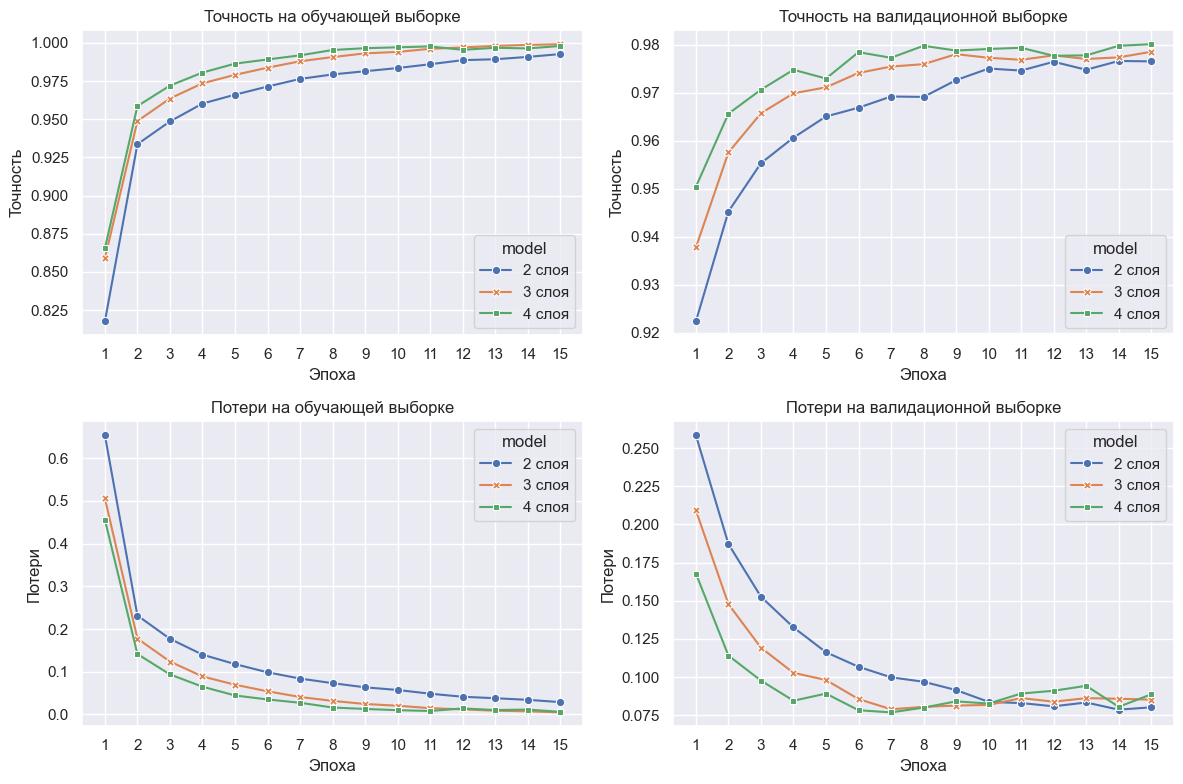

In [14]:
model_names = ["2 слоя", "3 слоя", "4 слоя"]

records_list = []

for history, model in zip([history1, history2, history3], model_names):
    for epoch, (train_acc, valid_acc, train_loss, valid_loss) in enumerate(zip(
        history.history["accuracy"],
        history.history["val_accuracy"],
        history.history["loss"],
        history.history["val_loss"]
    )):
        records_list.append({
            "model": model,
            "epoch": epoch + 1,
            "train_acc": train_acc,
            "valid_acc": valid_acc,
            "train_loss": train_loss,
            "valid_loss": valid_loss
        })

records = pd.DataFrame(records_list)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
axes = axes.flatten()

sns.lineplot(
    data=records, x="epoch", y="train_acc", hue="model",
    style="model", dashes=False, markers=True, ax=axes[0]
).set(
    title="Точность на обучающей выборке",
    xlabel="Эпоха", ylabel="Точность", xticks=range(1, n_epochs + 1)
)

sns.lineplot(
    data=records, x="epoch", y="valid_acc", hue="model",
    style="model", dashes=False, markers=True, ax=axes[1]
).set(
    title="Точность на валидационной выборке",
    xlabel="Эпоха", ylabel="Точность", xticks=range(1, n_epochs + 1)
)

sns.lineplot(
    data=records, x="epoch", y="train_loss", hue="model",
    style="model", dashes=False, markers=True, ax=axes[2]
).set(
    title="Потери на обучающей выборке",
    xlabel="Эпоха", ylabel="Потери", xticks=range(1, n_epochs + 1)
)

sns.lineplot(
    data=records, x="epoch", y="valid_loss", hue="model",
    style="model", dashes=False, markers=True, ax=axes[3]
).set(
    title="Потери на валидационной выборке",
    xlabel="Эпоха", ylabel="Потери", xticks=range(1, n_epochs + 1)
)

plt.tight_layout()

In [15]:
test_loss_1, test_acc_1 = model1.evaluate(x_test, y_test, verbose=0)
test_loss_2, test_acc_2 = model2.evaluate(x_test, y_test, verbose=0)
test_loss_3, test_acc_3 = model3.evaluate(x_test, y_test, verbose=0)

results = pd.DataFrame({
    "model": model_names,
    "params_count": [
        model1.count_params(),
        model2.count_params(),
        model3.count_params()
    ],
    "train_accuracy": [
        history1.history["accuracy"][-1],
        history2.history["accuracy"][-1],
        history3.history["accuracy"][-1],
    ],
    "train_loss": [
        history1.history["loss"][-1],
        history2.history["loss"][-1],
        history3.history["loss"][-1],
    ],
    "valid_accuracy": [
        history1.history["val_accuracy"][-1],
        history2.history["val_accuracy"][-1],
        history3.history["val_accuracy"][-1],
    ],
    "valid_loss": [
        history1.history["val_loss"][-1],
        history2.history["val_loss"][-1],
        history3.history["val_loss"][-1],
    ],
    "test_accuracy": [test_acc_1, test_acc_2, test_acc_3],
    "test_loss": [test_loss_1, test_loss_2, test_loss_3]
})

display(results.style.hide(axis="index"))

model,params_count,train_accuracy,train_loss,valid_accuracy,valid_loss,test_accuracy,test_loss
2 слоя,109386,0.992667,0.028919,0.976583,0.080165,0.975500,0.082574
3 слоя,242762,0.999146,0.004862,0.978583,0.085187,0.978600,0.080385
4 слоя,575050,0.997979,0.006213,0.980167,0.088676,0.980600,0.083060


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


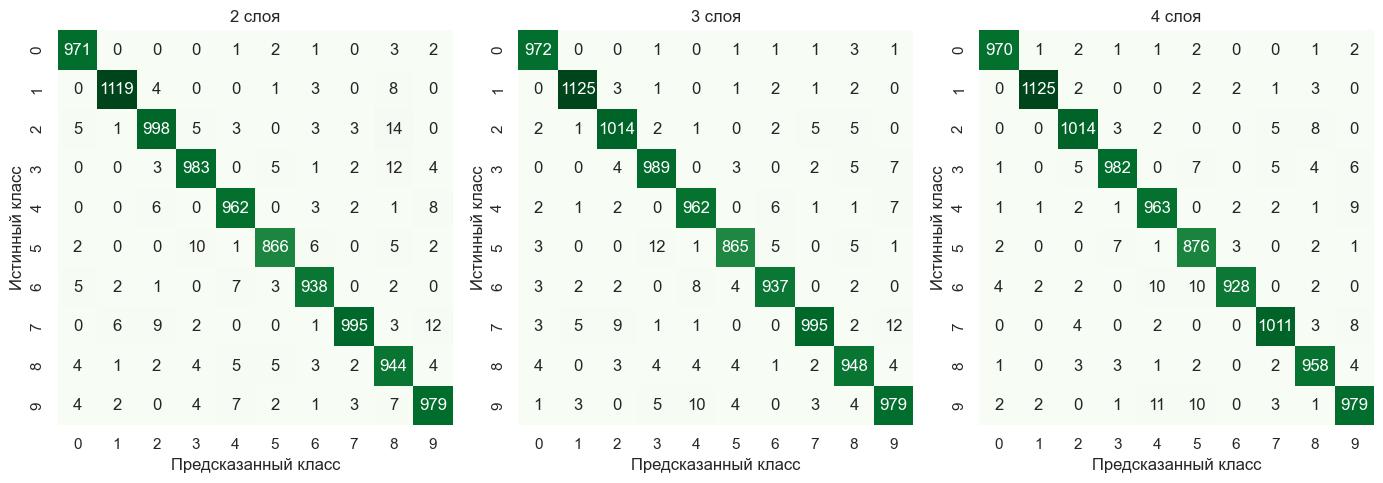

In [16]:
y_true = np.argmax(y_test, axis=1)

y_pred_proba_1 = model1.predict(x_test)
y_pred_proba_2 = model2.predict(x_test)
y_pred_proba_3 = model3.predict(x_test)

y_pred_1 = np.argmax(y_pred_proba_1, axis=1)
y_pred_2 = np.argmax(y_pred_proba_2, axis=1)
y_pred_3 = np.argmax(y_pred_proba_3, axis=1)

cm1 = confusion_matrix(y_true, y_pred_1)
cm2 = confusion_matrix(y_true, y_pred_2)
cm3 = confusion_matrix(y_true, y_pred_3)

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(14, 6))

for ax, cm, title in zip(axes, [cm1, cm2, cm3], model_names):
    sns.heatmap(
        cm, cmap="Greens", annot=True, fmt="d", cbar=False, square=True, ax=ax
    ).set(
        title=title, xlabel="Предсказанный класс", ylabel="Истинный класс"
    )

plt.tight_layout()

In [17]:
error_indices = np.where(
    (y_pred_1 != y_pred_2) & (y_pred_2 != y_pred_3) & (y_pred_1 != y_pred_3)
)[0]

len(error_indices)

14

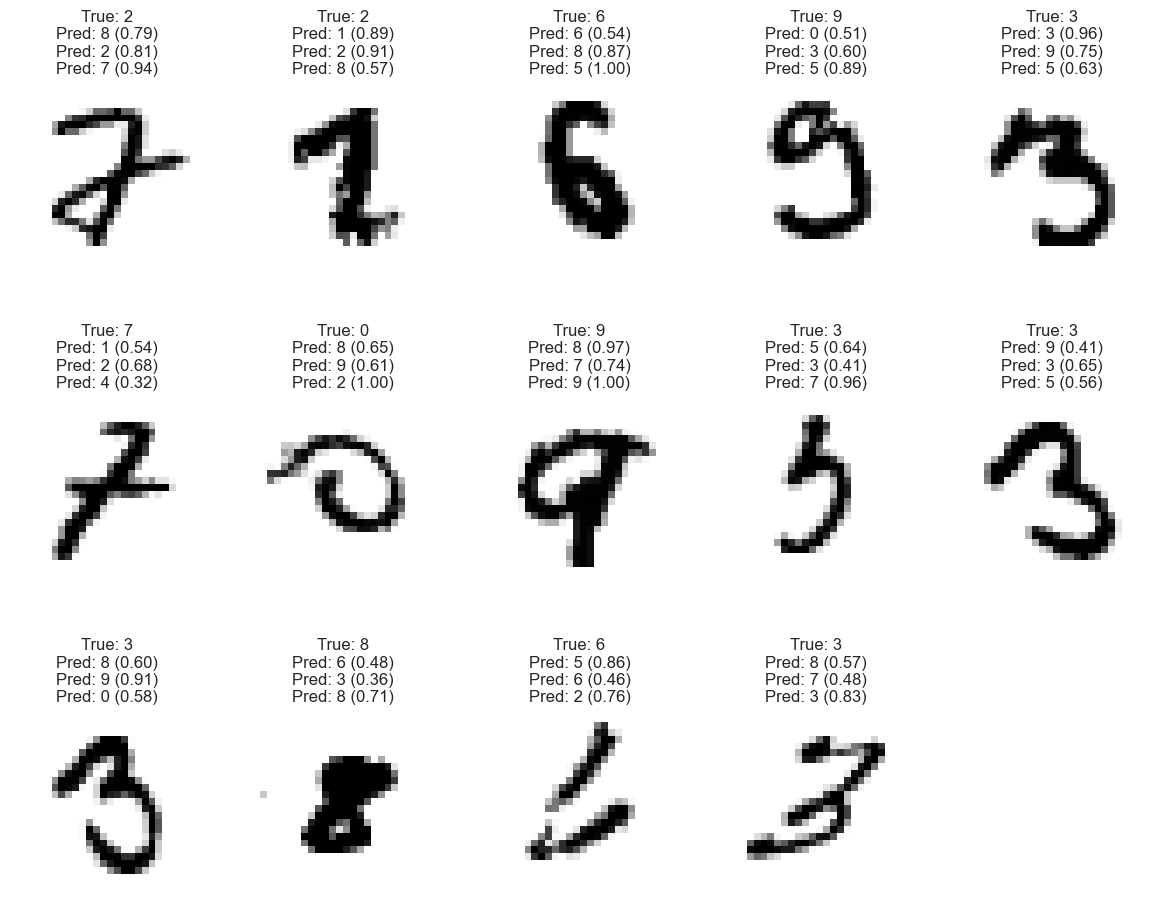

In [18]:
n_cols = 5
n_rows = ceil(len(error_indices) / n_cols)

_, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, n_rows * 3))
axes = axes.flatten()

for ax, error_index in zip(axes, error_indices):
    pred1 = y_pred_1[error_index]
    pred2 = y_pred_2[error_index]
    pred3 = y_pred_3[error_index]

    prob1 = y_pred_proba_1[error_index][pred1]
    prob2 = y_pred_proba_2[error_index][pred2]
    prob3 = y_pred_proba_3[error_index][pred3]
    
    ax.axis("off")
    ax.set_title(
        f"True: {y_true[error_index]}\n"
        f"Pred: {pred1} ({prob1:.2f})\n"
        f"Pred: {pred2} ({prob2:.2f})\n"
        f"Pred: {pred3} ({prob3:.2f})",
        pad=0
    )
    ax.imshow(x_test[error_index].reshape(28, 28), cmap="gray_r")

for ax in axes[len(error_indices):]:
    ax.axis("off")

plt.tight_layout(h_pad=6)